/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Image loaded: (451, 300)
Predicted: Egyptian Mau  (85.8%)


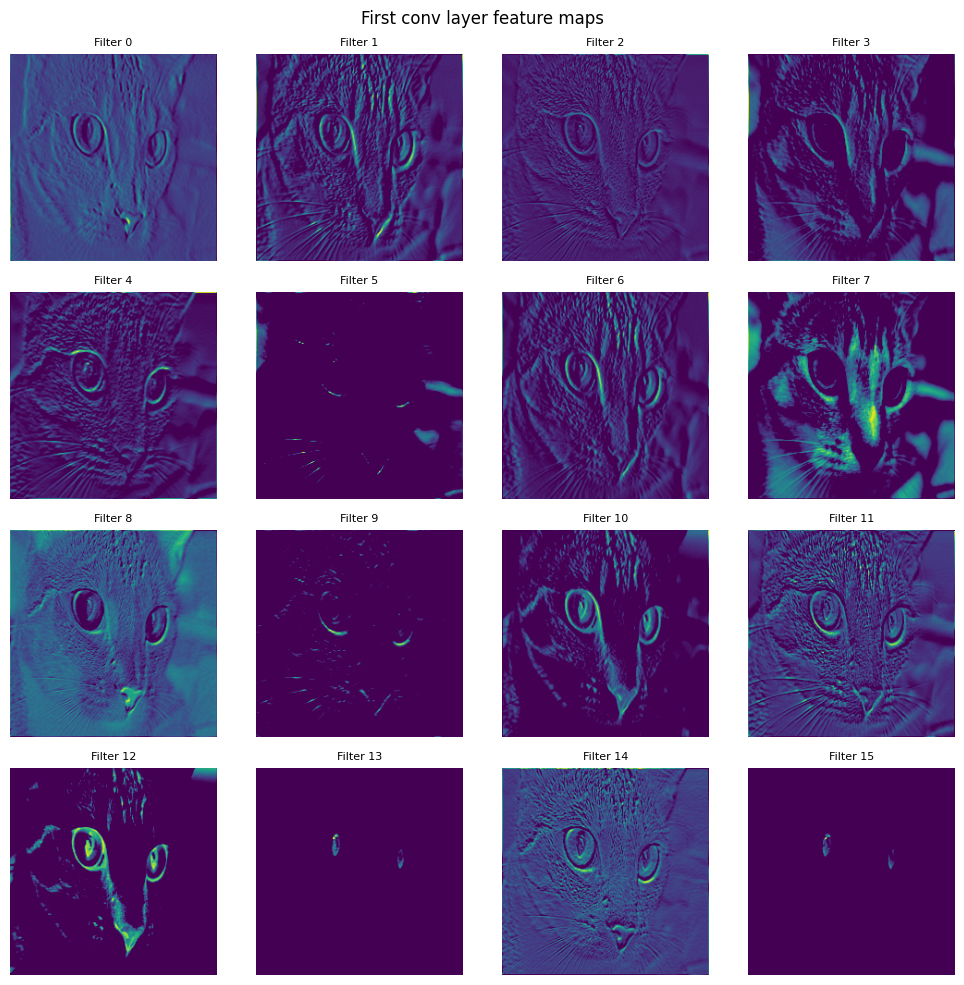

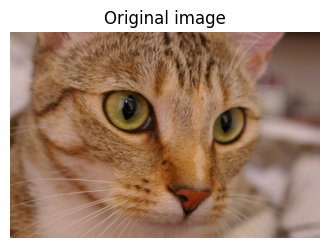

In [11]:
# Full cell - everything together
import urllib.request, json
import numpy as np
import torch
import torch.nn as nn
import torchvision
import matplotlib.pyplot as plt
from PIL import Image
from skimage import data

# Load VGG16
vgg16 = torchvision.models.vgg16(pretrained=True)
vgg16.eval()

# ImageNet classes
url = "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json"
with urllib.request.urlopen(url) as r:
    imagenet_classes = json.load(r)

# Preprocessing pipeline
mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def preprocess(img):
    img = img.convert('RGB')
    img = img.resize((224, 224), Image.BILINEAR)
    img = np.array(img, dtype=np.float32) / 255.0
    img = (img - mean) / std
    img = img.transpose((2, 0, 1))
    img = np.expand_dims(img, 0)
    return torch.Tensor(img)

# Load built-in cat image
img_array = data.cat()
img = Image.fromarray(img_array)
print("Image loaded:", img.size)

# Forward pass & prediction
x = preprocess(img)
with torch.no_grad():
    y = vgg16(x)
y = y.numpy()

probs      = torch.nn.functional.softmax(torch.Tensor(y), dim=1).numpy()
pred_idx   = np.argmax(probs)
pred_class = imagenet_classes[pred_idx]
confidence = probs[0, pred_idx]
print(f"Predicted: {pred_class}  ({confidence*100:.1f}%)")

# Feature maps after first conv layer
first_conv = nn.Sequential(*list(vgg16.features.children())[:2])
first_conv.eval()

x = preprocess(img)
with torch.no_grad():
    fmaps = first_conv(x)  # (1, 64, 224, 224)
fmaps = fmaps.numpy()[0]   # (64, 224, 224)

# Show first 16 feature maps
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(fmaps[i], cmap='viridis')
    ax.set_title(f'Filter {i}', fontsize=8)
    ax.axis('off')
plt.suptitle('First conv layer feature maps', fontsize=12)
plt.tight_layout()
plt.show()

# Show original image for comparison
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title('Original image')
plt.axis('off')
plt.show()